## Load Functions

In [96]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import time

In [97]:
def Marchenko_Pastur_significance_threshold(lam,var):
    sqrt = np.sqrt(lam)
    out1 = var*(1-sqrt)**2
    out2 = var*(1+sqrt)**2
    return (out1,out2)
    
def Marchenko_Pastur_distribution(lambda_min,lambda_max,lam,var):
    x_vector = np.linspace(lambda_min,lambda_max,10000)
    dx = x_vector[1]-x_vector[0]
    pdf = 1/(2*np.pi*var) * np.sqrt((lambda_max-x_vector)*(x_vector-lambda_min))/(lam*x_vector)
    return x_vector,pdf

In [98]:
def plot_matrix(matrix,cmap = 'RdBu',max_value=None,min_value=None,aspect=None,tight_layout=True,figsize=None,
               xticks = [],x_ticklabels = [],x_orientation=0,x_alignment='center',
                yticks = [],y_ticklabels = [],title=None,
               xlabel=None,ylabel=None,
                set_log_xscale=False,set_log_yscale=False,scale=None,
               cbar_label = None,x_fontsize=10,y_fontsize=10,
               savefig=False,format='png',out_dir='',data_name = '',
               draw_special_diagonal=False,diagonal_color='k'):

    if max_value==None:
        max_value = 1.1*np.max(matrix)
    if min_value==None:
        min_value = 1.1*np.min(matrix)
    norm_value = (colors.TwoSlopeNorm(vcenter=0,vmin=min_value,vmax=max_value) if cmap=='RdBu' else None)
    if scale=='log': norm_value='log'
    fig,ax = plt.subplots(figsize=figsize)
    heatmap = ax.imshow(
               matrix,
               cmap=cmap,
               aspect=aspect,
               norm=norm_value,
               vmax = (max_value if cmap=='Reds' or cmap=='Blues' else None),
                       )
    cbar = fig.colorbar(heatmap,label=cbar_label)
    if draw_special_diagonal ==True:
        for i in range(min(np.shape(matrix)[0],np.shape(matrix)[1])):
            rect = patches.Rectangle(
                (i - 0.5, i - 0.5),  # bottom-left corner (cell boundaries in imshow coordinates)
                1, 1,                # width, height (one cell)
                facecolor="black",
                edgecolor="none",
                zorder=3             # draw above the image
            )
            ax.add_patch(rect)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels(y_ticklabels,fontsize=y_fontsize)
    ax.set_xticklabels(x_ticklabels,rotation=x_orientation,ha=x_alignment,
                      fontsize=x_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if set_log_xscale == True:
        ax.set_xscale('log')
    if set_log_yscale==True:
        ax.set_yscale('log')
    if tight_layout==True:
        plt.tight_layout()
    if savefig==True:
        plt.savefig(os.path.join(out_dir,data_name)+str('.{}'.format(format)),format=format,dpi=300,transparent=True)
    plt.show()  

    return

In [99]:
from numba import njit

@njit
def species_growth_rates(R_vec,n_vec,
                 growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                ):
    ''' Growth of the species as a function of the resource abundances: g_i^\alpha(\vec{R},\vec{n})
    By default, we use nR/(1+R) on all resources.
    '''
    R_part = R_vec/(1+R_vec)
    outer = np.outer(R_part,n_vec) #Shape (N_R,N_n)
    outer = outer*growth_choices
    
    # if np.random.random()<1e-3:
    #     print('growth_rates',np.sum(outer>1e-3))
    #     print(outer[0,:])

    ''' Calculate also the total species growth rates '''
    species_total_growth_rate = np.sum(outer,axis=0) #shape (N_species)
    return outer,species_total_growth_rate

@njit
def resource_depletion_production(R_vec,n_vec,
                   total_species_growth_rate, #Shape (N_species)
                                  inv_yields):

    '''
    Calculates g_i^alpha*1/Y_i^\alpha
    '''

    resource_changes = total_species_growth_rate[None,:]*inv_yields #is shape (1,N_res,N_species). I don't know why there is the one

    # if np.random.random()<1e-3:
    #     print('production terms',resource_changes)
    
    return resource_changes

@njit
def d_resources(R_vec,n_vec,
               entry_rates,
                total_growth_rates,
                inv_yields):

    entry = entry_rates #shape (N_res)
    res_changes = resource_depletion_production(R_vec,n_vec,total_growth_rates,inv_yields)

    # if np.random.random()<1e-3:
    #     print('res_changes',res_changes)

    consumption_production = -np.sum(res_changes,axis=1) #Shape N_resource

    return entry+consumption_production

@njit
def d_species(n_vec,growth_rates):

    species_growth = np.sum(growth_rates,axis=0)

    return species_growth    
    
    
    
    

In [100]:
dataset_name = '2025.12.19.100_species_5_fed_resources' ### Good for manuscript SI
if os.path.exists(dataset_name)==False:
    os.mkdir(dataset_name)

In [101]:
''' System constants '''
N_species = 100
N_resources = 20
independent_species_cutoff = 100 #N_species #species beyond this cutoff exist independently of all others and are akin to noise
nsteps = 30000
dt = 0.005
dilution = 0.1

set_random_seed = True
if set_random_seed:
    np.random.seed(0)

## Create matrices and perform simulations 

Do not run this. Simulations are run in parallel in "functions.py"

In [12]:


''' Resource entries '''
entry_rates = np.zeros(N_resources)
how_many_suplied_resources = int(np.round(N_resources/5)+1e-4)
how_many_supplied_resources = N_resources
# how_many_supplied_resources = 5
if N_resources>1:
    entered_res = np.random.choice(min(independent_species_cutoff,N_resources),
                                   size=how_many_supplied_resources,
                                   replace=False)
else:
    entered_res = np.array([0])

if dataset_name == 'two_resources_one_high_one_low':
    entered_res = np.array([0,1])

# entered_res = np.random.choice(20,size=how_many_supplied_resources,replace=False)
entry_rates[entered_res] = np.abs(np.random.normal(0,1,size=len(entered_res))) #gaussian(0,1) 
if independent_species_cutoff<N_resources:
    entry_rates[independent_species_cutoff:] = np.abs(np.random.normal(0,1,size=N_species-independent_species_cutoff))#such that independent species also grow, in the absence of interactions with others.
# entry_rates[:independent_species_cutoff] = 1 #to make all species the same for the independent dataset

''' Inverse yields and growth preferences '''
inv_yields = np.zeros((N_resources,N_species))#np.random.normal(0,1,N_resources*N_species).reshape((N_resources,N_species))
growth_choices = np.zeros((N_resources,N_species))
for sp in range(N_species):

    
    if sp<independent_species_cutoff:
        if dataset_name == 'single_resource_high_fluctuation': res = 0; inv_yields[res,sp] = 1.0; growth_choices[res,sp] = 1.0; continue
        if dataset_name == 'two_resources_one_high_one_low':
            res  = int(sp//(N_species/2))
            inv_yields[res,sp] = 1.0
            growth_choices[res,sp] = 1.0
            continue

        eats_single_resource = True
        if eats_single_resource:
            ''' If eating one resource '''
            # res = np.random.choice(independent_species_cutoff) #if random
            # res = sp%N_resources #if non-random
            res = sp//5 #if guilded
            # res = sp//7 #for the CR-batch simulation
            # growth_choices[res,sp] = 1.0 #species eats the chosen resource
            inv_yields[res,sp] = 1.0 #consumption yield. You can add some noise for the CR-batch-like  simulation.
            growth_choices[res,sp] = 1.0 #species eats the chosen resource
        else:
            ''' If eating multiple resources '''
            how_many_res_eaten = 4-1
            eaten_resources = np.random.choice(sp,size= min(how_many_res_eaten,sp),replace=False)
            growth_choices[eaten_resources,sp] = 1.0
            inv_yields[eaten_resources,sp] = 1.0
            growth_choices[sp,sp] = 1.0; inv_yields[sp,sp] = 1.0
    else:
        res = sp%N_resources
        growth_choices[res,sp] = 1.0 #species eats the chosen resource
        inv_yields[res,sp] = 1.0 #consumption yield
    
   
    
    

    
    if sp>=independent_species_cutoff:
        ''' For independent species, give them a yield that makes them scale across several orders of magnitude '''
        if independent_species_cutoff<N_resources:
            inv_yields[res,sp] = 10**(2*np.random.random()) #to make independent species span several orders of magnitude
        else:
            inv_yields[res,sp] = 1.0 #all independent species have the same yield. You can then rescale their abundances to match other species abundances.

    if sp<independent_species_cutoff:
        # produceable_species = np.delete(np.arange(N_species),res) #select from all resources except the eaten one
        # produceable_species = np.arange(res+1,res+independent_species_cutoff) #select from the next resources, wrt to eaten resource, in the network
        # produceable_species = np.arange(sp+1,min(sp+independent_species_cutoff,N_species)) #select from the next resources, wrt species, in the network
        # produceable_species = [(res+1)%N_resources] #produce only next resource
        # produceable_species = np.arange(res+1,min(res+N_resources,N_resources)) #for 2025.10.22
        # produceable_species = [res+1] if res<N_resources-1 else []
        produceable_species = np.arange((sp//5+1),
                                        # N_resources #produces any resources downstream
                                        (sp//5+6), #produces only from amongst the next 5 resources
                                       )
        # produceable_species = [2] if sp//7<2 else [] #For CR-batch-like simulations
        
        if len(produceable_species)>0:
            how_many_secreted_resources = 2
            produced_res = np.random.choice(produceable_species,size=how_many_secreted_resources,
                                           ) #Resources produced by the species
            produced_res = produced_res[produced_res<N_resources]
            produced_res = produced_res%N_resources
            
            # produced_res = produced_res[produced_res<independent_species_cutoff] #cannot produce resources that have no corresponding species
            inv_yields[produced_res,sp] = -1/how_many_secreted_resources #-0.5 #resource is produced
        




In [13]:
inv_yields_complete = np.copy(inv_yields)
growth_choices_complete = np.copy(growth_choices)

''' Dump these arrays to they can be loaded from the functions.py file '''

with open('inv_yields_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

In [57]:
# nsteps = 400000

if which_option!='A': print('You did not select this option!'); 
else:
    species_abus = np.random.random(N_species)
    resource_abus = np.random.random(N_resources)
    
    res_noise_weights = 1e-5#np.linspace(1e-5,1e-1,N_resources) #this way there are different noise levels for different resource-mediated interactions
    
    
    species_traces_full = []
    resource_traces_full = []

    # ''' Resource entries '''
    # entry_rates = np.zeros(N_resources)
    # entered_res = np.random.choice(independent_species_cutoff,size=5,replace=False)
    # entry_rate_sigma = 10
    # entry_rates[entered_res] = np.abs(np.random.normal(0,entry_rate_sigma,size=len(entered_res))) #gaussian(0,1) 
    # entry_rates[independent_species_cutoff:] = np.abs(np.random.normal(0,entry_rate_sigma,size=N_species-independent_species_cutoff))#such that independent species also grow, in the absence of interactions with others.

    
    # ''' Prepare colored noise ''' 
    # sigma_outside = 0.1*entry_rate_sigma
    # sigma_inside = 0.1*entry_rate_sigma
    # outside_resource_noise_prev = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>0) #noise for supplied resources is large
    # inside_resource_noise_prev = np.random.normal(0,sigma_inside,size=(N_resources))*np.sqrt(dt)*(entry_rates<1e-10) #noise for cross-fed resources is small
    # tau = 0.0001#autocorrelation time of the resource noise

    ''' Resource entries. Supplied resources are always the same, but their entry rates are random. '''
    entry_rates = np.zeros(N_resources)
    # entered_res = np.random.choice(min(N_resources,independent_species_cutoff),size=N_resources,replace=False)
    # entered_res = [7,13,14,18,19]
    if dataset_name == 'single_resource_high_fluctuation':
        entered_res = np.array([0])
    elif dataset_name == 'two_resources_one_high_one_low':
        entered_res = np.array([0,1])
    else:
        entered_res = np.random.choice(N_resources,size=how_many_supplied_resources-1,replace=False)
        entered_res = np.concatenate(([0],entered_res)) #always supply resource 0 to avoid having unused resources.
    # entry_rate_sigma = 1
    # entry_rate_mean = entry_rate_sigma
    entry_rate_mean = 2 #From 2025.10.17.4:02pm
    entry_rate_sigma = entry_rate_mean

    ### For CR-batch-like simulations ###
    # entry_rates = np.random.random(3)*10
    # entry_rates[2] = 0
    print('entry_rates',
          entry_rates)

    
    ### Truncated gaussian entry rate
    # entry_rates[entered_res] = np.abs(np.random.normal(entry_rate_mean,entry_rate_sigma,size=len(entered_res))) #gaussian(0,1) 
    # if independent_species_cutoff<N_resources:
    #     entry_rates[independent_species_cutoff:] = np.abs(np.random.normal(entry_rate_mean,entry_rate_sigma,size=N_resources-independent_species_cutoff))
    ### Entry rates sampled from uniform
    # entry_rates[entered_res] = np.random.random(size=len(entered_res))*10
    ### Same entry rate for all
    entry_rates[entered_res] = 10#entry_rate_mean
    

    
    # fig,ax = plt.subplots() #is ok
    # ax.bar(np.arange(len(entry_rates)),entry_rates)
    # plt.show()

    
    print('enterd res.',entered_res)
    print('PID',os.getpid(),entry_rates[0])
    
    species_abus = np.random.random(N_species)
    # For CR-batch-like simulations. Start species in group 1 and 2 at higher abundances than species in group 3
    # species_abus[:7] *= 10
    # species_abus[7:14] *= 10
    # species_abus[14:] *= 0.2
    resource_abus = np.random.random(N_resources)
    

    time0 = time.time()


    ''' Prepare colored noise ''' 
    sigma_outside = 10 #From 2025.10.17.4:01pm
    sigma_inside = 10
    outside_resource_noise_prev = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>0) #noise for supplied resources is large
    inside_resource_noise_prev = np.random.normal(0,sigma_inside,size=(N_resources))*np.sqrt(dt)*(entry_rates<1e-10) #noise for cross-fed resources is small
    tau = 0.000001#autocorrelation time of the resource noise

    
    for step in range(nsteps):
        if step%1000==0: print('{:.3f}%'.format(step/nsteps*100))
        species_traces_full.append(np.copy(species_abus))
        resource_traces_full.append(np.copy(resource_abus))
        
    
        
        ''' Growth rates '''
        growth_rates,total_growth_rate_per_species = species_growth_rates(resource_abus,species_abus,
                     growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                    )
        
        
        # if np.random.random()<1e-3: print('growth_rates',growth_rates[0,:])
        
        d_res = d_resources(resource_abus,species_abus,
                   entry_rates,
                            total_growth_rate_per_species,
                   inv_yields)-resource_abus*dilution
        # if step%100==0:
        #     # print('growth_rates',total_growth_rate_per_species[10:15],total_growth_rate_per_species[50:55])
        #     # print('entry_rates \n',#growth_rates[10:15,10:15],'\n',
        #     #       entry_rates[50:55])
        #     # print('total_growth_rate \n',#growth_rates[10:15,10:15],'\n',
        #     #       growth_rates[50:55,50:55])
        #     print('resource_depletion_production \n',
        #           resource_depletion_production(resource_abus,species_abus,total_growth_rate_per_species,inv_yields)[10:25,10:25])
            
                
        # if np.random.random()<1e-3: 
        #     # print('d_res',d_res); 
        #     print('d_resources',d_resources(resource_abus,species_abus,
        #            entry_rates,growth_rates,inv_yields))
        
        d_sp = d_species(species_abus,growth_rates)-species_abus*dilution
        sp_noise = np.random.normal(0,1,size=(N_species))*np.sqrt(dt)
        
        species_abus += d_sp*dt +sp_noise

                  

        thres = 1e-10
        ''' Time-correlated noise '''
        # outside_resource_noise = (np.exp(-dt/tau)*outside_resource_noise_prev
        #     +np.sqrt(1-np.exp(-2*dt/tau))*np.random.normal(0,sigma_outside,size=(N_resources)))*np.sqrt(dt)*(entry_rates>=thres) #noise for supplied resources is large
        # inside_resource_noise = (np.exp(-dt/tau)*inside_resource_noise_prev
        #     +np.sqrt(1-np.exp(-2*dt/tau))*np.random.normal(0,sigma_inside,size=(N_resources)))*np.sqrt(dt)*(entry_rates<thres) #noise for cross-fed resources is small
        
        ''' WHite noise '''
        outside_resource_noise = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>=thres) #noise for supplied resources is large
        inside_resource_noise = np.random.normal(0,sigma_inside,size=(N_resources))*np.sqrt(dt)*(entry_rates<thres) #noise for cross-fed resources is small
        
        
        outside_resource_noise[resource_abus<thres] = 0
        inside_resource_noise[resource_abus<thres] = 0

        # if step%100==0:
        #     print('inside_res_noise \n',
        #           inside_resource_noise[50:55],'\n',
        #           'outside_resource_noise \n',
        #           outside_resource_noise[50:55])
        
        # if step%100==0:
        #     # print('growth_rates',total_growth_rate_per_species[10:15],total_growth_rate_per_species[50:55])
        #     print('d_species',d_species(species_abus,growth_rates)[10:15],d_species(species_abus,growth_rates)[50:55])
            
        #     print('d_res',d_res[10:15],d_res[50:55])
        
        resource_abus += d_res*dt+outside_resource_noise+inside_resource_noise
        resource_abus[resource_abus<thres] = 0
        species_abus[species_abus<thres] = 0

        outside_resource_noise_prev = outside_resource_noise
        inside_resource_noise_prev = inside_resource_noise
    
    inv_yields_complete = np.copy(inv_yields)
    growth_choices_complete = np.copy(growth_choices)

entry_rates [0.]
enterd res. [0]
PID 11888 10.0
0.000%
3.333%
6.667%
10.000%
13.333%
16.667%
20.000%
23.333%
26.667%
30.000%
33.333%
36.667%
40.000%
43.333%
46.667%
50.000%
53.333%
56.667%
60.000%
63.333%
66.667%
70.000%
73.333%
76.667%
80.000%
83.333%
86.667%
90.000%
93.333%
96.667%


In [58]:
supplied_resources = np.copy(entered_res)
print(supplied_resources)

[0]


In [62]:

resource_traces_full = np.array(resource_traces_full)
species_traces_full = np.array(species_traces_full)

species_traces = np.copy(species_traces_full)
resource_traces = np.copy(resource_traces_full)

[0]
[0.09661616]


Text(0, 0.5, 'n')

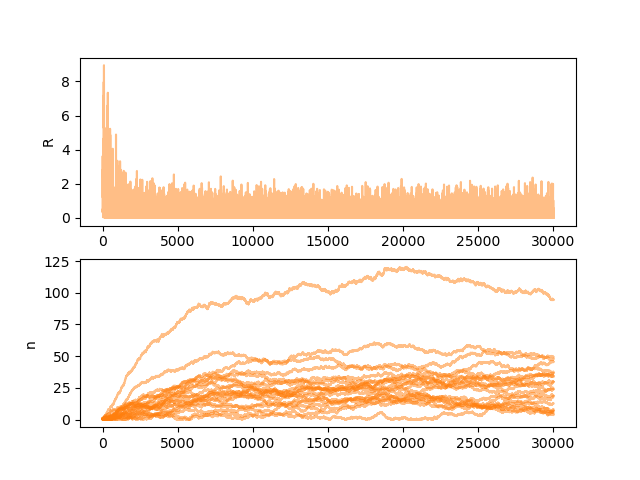

In [60]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(2,1)
# ax[0].plot(resource_traces_full[:,[50,51,52]])
for res in range(N_resources):
    if res in entered_res:
        ax[0].plot(resource_traces_full[:,res],'tab:orange',alpha=0.5)
    else:
        ax[0].plot(resource_traces_full[:,res],'tab:blue',alpha=0.5)
res_vars = np.var(resource_traces_full[-10000:,:],axis=0)
print(entered_res)
print(res_vars)
ax[0].set_ylabel('R')
# ax[1].plot(species_traces_full)
for s in range(N_species):
    if np.sum(inv_yields[entered_res,s])>0: #species consumes entered resource
        ax[1].plot(species_traces_full[:,s],'tab:orange',alpha=0.5)
    else:
        ax[1].plot(species_traces_full[:,s],'tab:blue',alpha=0.5)
ax[1].set_ylabel('n')
# ax[1].set_yscale('log')
# ax[0].set_yscale('log')

In [40]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection


if 'CR_batch' in dataset_name:
    projections = inv_yields[2,:][None,:]*(species_traces_full-np.mean(species_traces_full,axis=0))
    (N1,N2,N3) = (np.sum(projections[:,:N_species//3+1],axis=1),
                  np.sum(projections[:,N_species//3+1:2*(N_species//3)+1],axis=1),
                  np.sum(projections[:,2*(N_species//3)+1:],axis=1))

# Stack points
points = np.array([N1[::10], N2[::10], N3[::10]]).T

# Create line segments
segments = np.concatenate(
    [points[:-1, None, :], points[1:, None, :]],
    axis=1
)

# Color parameter (from 0 to 1)
t = np.linspace(0, 1, len(segments))

# Create the 3D line collection
lc = Line3DCollection(segments, cmap='coolwarm',)
lc.set_array(t)
lc.set_linewidth(2)


normal = np.array((1,1,1))
xx, yy = np.meshgrid(range(-40,40), range(-40,40))
d=0
z = (-normal[0] * xx - normal[1] * yy - d) * 1. /normal[2]

%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xx, yy, z, alpha=0.2)
# ax.plot(N1,N2,N3,)
ax.add_collection(lc)
cbar = fig.colorbar(lc, ax=ax, pad=0.1)
cbar.set_label('Time (a.u.)')

ax.set_xlim(-40,40)
ax.set_ylim(-40,40)
ax.set_zlim(-40,40)

NameError: name 'N1' is not defined

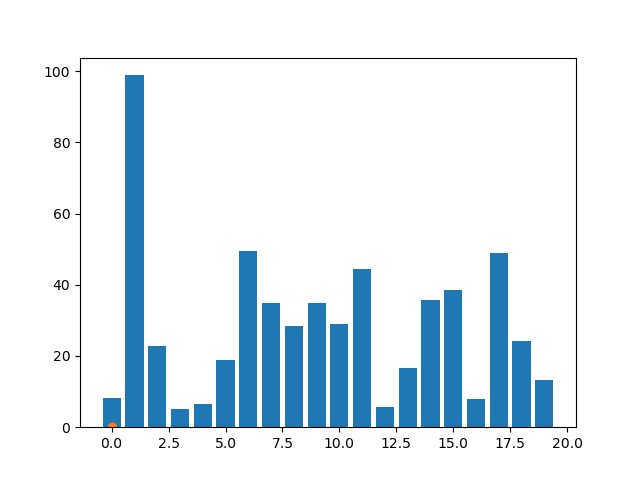

In [92]:
fig,ax = plt.subplots()
ax.bar(np.arange(N_species),
       np.mean(species_traces_full[-1000:,:],axis=0))
ax.scatter(np.arange(N_resources)[entry_rates>0]*5,[0]*len(supplied_resources))
# ax.set_yscale('log')

In [189]:
''' Plot abundances of cross-fed species pairs to check, by eye, if they are correlated or not '''
species_that_feed_on_external_resources = np.arange(N_species)[(entry_rates>0.1) & (np.arange(N_species)<independent_species_cutoff)]
species_that_feed_on_external_resources = np.arange(10)
fig,ax = plt.subplots()
for s in species_that_feed_on_external_resources:
    print(s,entry_rates[s])
    ax.scatter(species_traces_full[:,s],
               species_traces_full[:,(s+1)%N_resources])
ax.set_xlabel(r'$x_i$')
ax.set_xlabel(r'$x_{i+1}$')

ValueError: operands could not be broadcast together with shapes (20,) (100,) 

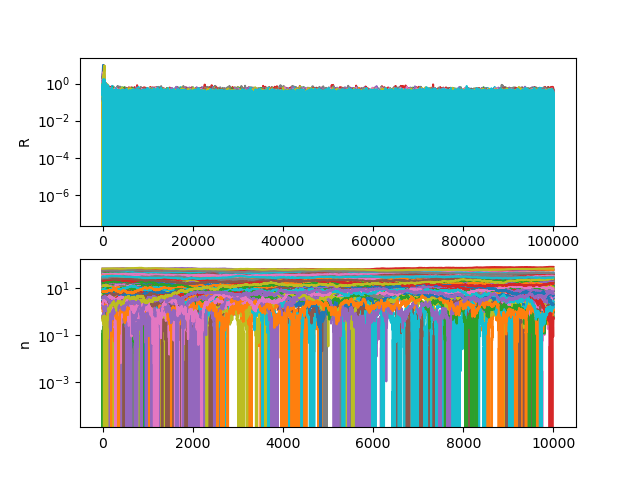

In [270]:
''' Keep only extant species in steady state '''
last_T = 10000
means_full = np.mean(species_traces_full[-last_T:,:],axis=0)
threshold = 1e-3 #in practice, from the plots above
which_species_to_keep = means_full>threshold
species_traces = species_traces_full[-last_T:,which_species_to_keep]

inv_yields = inv_yields_complete[:,which_species_to_keep]
growth_choices = growth_choices_complete[:,which_species_to_keep]

fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[0].set_yscale('log')
ax[1].plot(species_traces)
ax[1].set_ylabel('n')
ax[1].set_yscale('log')

In [ ]:
print(species_traces.shape,autocorrelations.shape)

In [ ]:
species_abus.shape

In [ ]:
inv_yields_complete = np.copy(inv_yields)
growth_choices_complete = np.copy(growth_choices)

with open('inv_yields_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

In [45]:
import time
if which_option!='B': print('You did not select this option!');
else:

    import functions
    import itertools
    
    how_many_simulations = 20
    nsteps=2000
    inv_yields_complete = np.copy(inv_yields)
    growth_choices_complete = np.copy(growth_choices)
    
    ''' Keep the name "traces" for compatibility with option A, even if these is cross-sample data '''
    species_traces_full = []
    resource_traces_full = []

    time0 = time.time()
    for sim in range(how_many_simulations):
        species_abus = np.random.random(N_species)
        resource_abus = np.random.random(N_resources)
        if sim%1==0: print('{:.3f}%, {:.3f} s'.format(sim/how_many_simulations*100,time.time()-time0))
        
        res_noise_weights = 1e-5#np.linspace(1e-5,1e-1,N_resources) #this way there are different noise levels for different resource-mediated interactions
        
        for step in range(nsteps):
            # if step%1000==0: print('{:.3f}%'.format(step/nsteps*100))
            
            ''' Growth rates '''
            growth_rates,total_growth_rate_per_species = species_growth_rates(resource_abus,species_abus,
                         growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                        )
        
            
            
            d_res = d_resources(resource_abus,species_abus,
                       entry_rates,
                                total_growth_rate_per_species,
                       inv_yields)-resource_abus*dilution
        
            
            d_sp = d_species(species_abus,growth_rates)-species_abus*dilution+1e-8
            
            species_abus += d_sp*dt+species_abus*np.random.normal(0,1e-1,size=(N_species))*np.sqrt(dt)
            resource_abus += d_res*dt#+np.random.normal(0,1,size=(N_resources))*np.sqrt(dt)
            resource_abus[resource_abus<1e-10] = 1e-10
            species_abus[species_abus<1e-10] = 1e-10
        species_traces_full.append(np.copy(species_abus))
        resource_traces_full.append(np.copy(resource_abus))
    print('Time take: {:.3f} s'.format(time.time()-time0))
    
species_traces_full = np.array(species_traces_full)
resource_traces_full = np.array(resource_traces_full)

0.000%, 0.000 s
5.000%, 4.349 s
10.000%, 8.666 s
15.000%, 13.021 s
20.000%, 17.460 s
25.000%, 21.786 s
30.000%, 26.096 s
35.000%, 30.608 s
40.000%, 34.889 s
45.000%, 39.132 s


KeyboardInterrupt: 

In [ ]:
with open('species_traces_full.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(species_traces_full,f)
    f.close()
with open('resource_traces_full.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(resource_traces_full,f)
    f.close()


In [ ]:
with open('species_traces_full.{}.dat'.format(dataset_name),'rb') as f:
    species_traces_full = pickle.load(f)
    f.close()
with open('resource_traces_full.{}.dat'.format(dataset_name),'rb') as f:
    resource_traces_full = pickle.load(f)
    f.close()

with open('inv_yields_complete.{}.dat'.format(dataset_name),'rb') as f:
    inv_yields_complete = pickle.load(f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'rb') as f:
    growth_choices_complete = pickle.load(f)
    f.close()

In [ ]:
species_traces_full.shape

In [ ]:
species_traces_full = np.array(species_traces_full)
resource_traces_full = np.array(resource_traces_full)

In [ ]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[1].plot(species_traces_full)
ax[1].set_ylabel('n')
# ax[1].set_yscale('log')
ax[0].set_yscale('log')
ax[1].set_xlabel('Sample')

In [ ]:
''' Keep only extant species across samples '''
means_full = np.mean(species_traces_full,axis=0)
threshold = 1e-3 #in practice, from the plots above
which_species_to_keep = means_full>threshold
species_traces = species_traces_full[:,which_species_to_keep]

inv_yields = inv_yields_complete[:,which_species_to_keep]
growth_choices = growth_choices_complete[:,which_species_to_keep]

fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[0].set_yscale('log')
ax[1].plot(species_traces)
ax[1].set_ylabel('n')
ax[1].set_yscale('log')

In [ ]:
np.shape(species_traces_full)

In [34]:
inv_yields_complete = np.copy(inv_yields)
growth_choices_complete = np.copy(growth_choices)

''' Dump these arrays to they can be loaded from the functions.py file '''

with open('inv_yields_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

In [64]:
import time
if which_option!='C': print('You did not select this option!');
else:

    import functions

#     import itertools
#     import multiprocess as mp
#     from pathos.multiprocessing import ProcessingPool as Pool
#     # from multiprocessing.dummy import Pool as ThreadPool
    
#     how_many_simulations = 20
#     nsteps=2000
#     inv_yields_complete = np.copy(inv_yields)
#     growth_choices_complete = np.copy(growth_choices)
    
#     ''' Keep the name "traces" for compatibility with option A, even if these is cross-sample data '''
#     species_traces_full = np.zeros((how_many_simulations,N_species))
#     resource_traces_full = np.zeros((how_many_simulations,N_resources))

#     sims = np.arange(how_many_simulations)

#     simulation_arguments = (how_many_simulations,N_species,N_resources,nsteps,
#                              growth_choices,entry_rates,inv_yields,
#                              dilution,dt)
    
#     args = [(sim,simulation_arguments) for sim in sims]

#     print('Starting simulations...')
#     time0 = time.time()
#     if __name__=='__main__':
#         pool = Pool(10)
#         with pool as p:
#             results = p.map(functions.main_simulation,args)
    
#     print('Simulations ended. Time taken: {:.3f} s'.format(time.time()-time0))
        
#     for result in results:
#         sim,resource_abus,species_abus = result

#         species_traces_full[sim,:] = species_abus
#         resource_traces_full[sim,:] = resource_abus
    
# species_traces_full = np.array(species_traces_full)
# resource_traces_full = np.array(resource_traces_full)

OMP_NUM_THREADS = 1


In [49]:
import pathos

In [62]:
import importlib

importlib.reload(functions)

<module 'functions' from 'D:\\Víctor\\Universitat\\PhD\\Projects\\Predicting Community Functions\\Uncovering Functional Groups\\Linear_Model\\Linear Regression For Relative Abundances\\2025.09.28.Consumer_resource_model\\functions.py'>

In [27]:
with open('species_traces_full.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(species_traces_full,f)
    f.close()
with open('resource_traces_full.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(resource_traces_full,f)
    f.close()


## Data Analysis

In [102]:
with open('{}/species_traces_full.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    species_traces_full = pickle.load(f)
    f.close()
    
species_traces = np.copy(species_traces_full)
with open('{}/resource_traces_full.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    resource_traces_full = pickle.load(f)
    f.close()
resource_traces = np.copy(resource_traces_full)

with open('{}/supplied_resources.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    supplied_resources = pickle.load(f)
    f.close()

with open('{}/inv_yields_complete.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    inv_yields_complete = pickle.load(f)
    inv_yields = np.copy(inv_yields_complete)
    f.close()
with open('{}/growth_choices_complete.{}.dat'.format(dataset_name,dataset_name),'rb') as f:
    growth_choices_complete = pickle.load(f)
    f.close()

print('Supplied resources',supplied_resources)

Supplied resources [ 0  1  9 11 14]


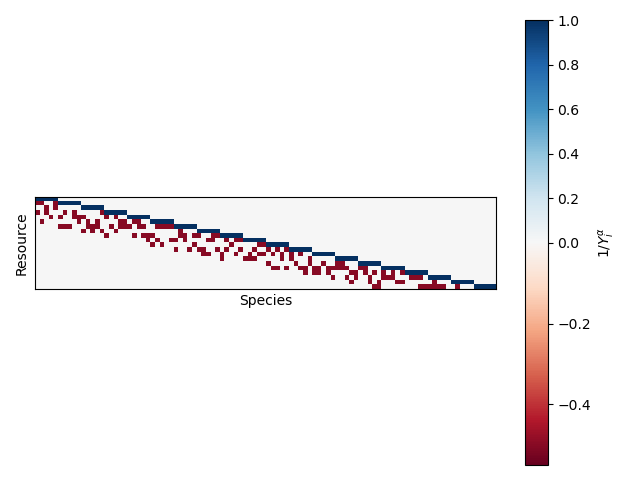

In [103]:
plt.close('all')
%matplotlib widget
# fig,ax = plt.subplots()
# # ax.bar(np.arange(N_resources),entry_rates)
plot_matrix(inv_yields,
            xticks = [],#np.arange(N_species),x_ticklabels = np.arange(N_species),
            yticks = [],#np.arange(N_resources), y_ticklabels = np.arange(N_resources),
            max_value = 1,
           xlabel='Species',
           ylabel='Resource',
            cmap='RdBu',
           cbar_label = r'$1/Y_i^\alpha$',savefig=False,format='svg',data_name='inv_yields.{}'.format(dataset_name))
plt.savefig('{}/inv_yields.{}.png'.format(dataset_name,dataset_name),format='png',transparent=True)
plt.savefig('{}/inv_yields.{}.svg'.format(dataset_name,dataset_name),format='svg',transparent=True)



In [104]:
relative_abundances_bool = False
if relative_abundances_bool:
    data = species_traces/np.sum(species_traces,axis=1)[:,None] #Relative Abundance Data
else:
    data  = species_traces #Absolute abundance data
# data = data[-2000:,means>0.002]
means = np.mean(data,axis=0)
vars = np.var(data,axis=0)
N_species = np.shape(data)[1]

beta_inferred 1.265740079652292


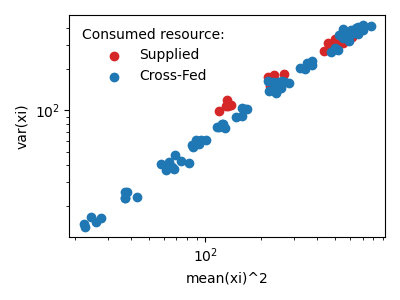

In [105]:
''' Check Taylor's Law '''
# means = np.mean(species_traces,axis=0)#/np.sum(species_traces,axis=1)[:,None],axis=0)
# vars = np.var(species_traces,axis=0)#/np.sum(species_traces,axis=1)[:,None],axis=0)
fig, ax = plt.subplots(figsize=(4,3))
plotted_labels = []
for s in range(N_species):
    if s<independent_species_cutoff:
        species_inv_yields = inv_yields[:,s]
        eats_supplied_resource = np.sum(species_inv_yields[supplied_resources]>0)>0
        if eats_supplied_resource:
            color = 'tab:red'
            label = 'Supplied'
            label = label if label not in plotted_labels else None
        else:
            color = 'tab:blue'
            label = 'Cross-Fed'
            label = label if label not in plotted_labels else None
    else:
        color = 'tab:orange'
        label = 'Independent'
        label = label if label not in plotted_labels else None
    ax.scatter(means[s]**2,vars[s],
              c=color,
              label=label)
    plotted_labels.append(label)
beta_inferred = np.mean(means**2/vars)
print('beta_inferred',np.sqrt(beta_inferred))
ax.legend(loc='best',frameon=False,title='Consumed resource:')
ax.set_xlabel('mean(xi)^2')
ax.set_ylabel('var(xi)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('{}/Taylor_law.{}.png'.format(dataset_name,dataset_name),format='png',transparent=True)
plt.savefig('{}/Taylor_law.{}.pdf'.format(dataset_name,dataset_name),format='pdf',transparent=True)


In [106]:
sample_abus = np.sum(data,axis=1)
N_mean = np.mean(sample_abus)
sigma_N  = np.std(sample_abus)

print('Total sample abundances: {:.3f}+-{:.3f}'.format(N_mean,sigma_N))

Total sample abundances: 1608.167+-268.127


1.3657329321851894


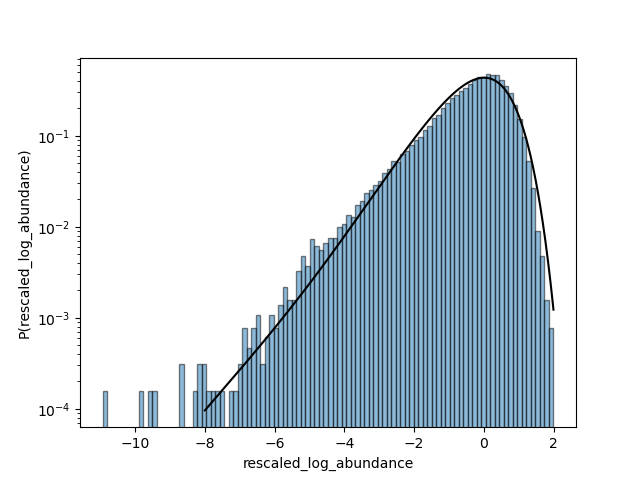

In [107]:
''' Check Gamma Distributions '''
from scipy.stats import gamma

rescaled_abundances = data/np.mean(data,axis=0)[None,:]


gamma_params = gamma.fit(rescaled_abundances.flatten(),2.5)
gamma_func = gamma(a=gamma_params[0],loc=gamma_params[1],scale=gamma_params[2])
print(gamma_params[0])

# gamma_func.fit(rescaled_abundances.flatten())


log_rescaled_abundances = np.log(rescaled_abundances[rescaled_abundances>0])

counts,bins = np.histogram(log_rescaled_abundances.flatten(),bins=100,
                          density=True)
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

fig,ax = plt.subplots()
ax.bar(bin_centers,
       counts,
       width= dbin,
       alpha=0.5,edgecolor='k')
x_vect = np.linspace(max(np.min(rescaled_abundances),np.exp(-8)),np.max(rescaled_abundances),10000)

gamma_pdf = gamma_func.pdf(x_vect)

ax.plot(np.log(x_vect),gamma_pdf*x_vect,'k')
ax.set_yscale('log')
ax.set_xlabel('rescaled_log_abundance')
ax.set_ylabel('P(rescaled_log_abundance)')
plt.savefig('{}/Gamma_distribution.{}.png'.format(dataset_name,dataset_name),format='png',transparent=True)
plt.savefig('{}/Gamma_distribution.{}.pdf'.format(dataset_name,dataset_name),format='pdf',transparent=True)

In [108]:
np.shape(data)
data_nonrescaled = np.copy(data)

In [109]:
''' Rescale abundances by their own standard deviation, as in z-scoring but without subtracting the mean '''
data  = (data_nonrescaled-means[None,:])/np.std(data_nonrescaled,axis=0)[None,:]
data = np.copy(data_nonrescaled)

In [110]:

cov_matrix = np.corrcoef(data.T)

true_eigvals,true_eigvects = np.linalg.eigh(cov_matrix)

argsorted_true_eigvals = np.argsort(true_eigvals)
true_eigvals=true_eigvals[argsorted_true_eigvals]
true_eigvects = true_eigvects[:,argsorted_true_eigvals]


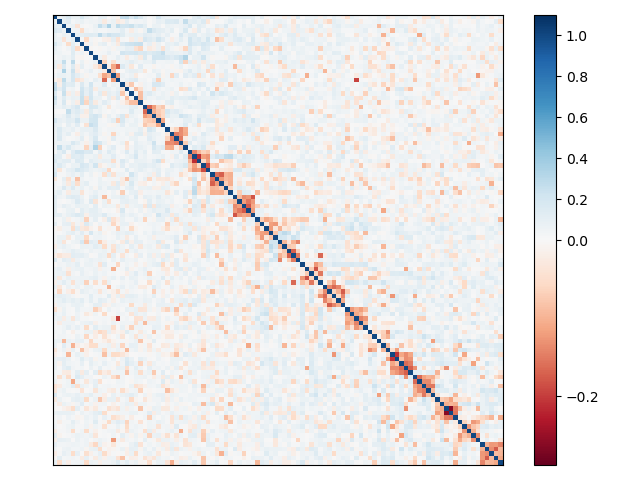

In [111]:
plot_matrix(cov_matrix,
           # cmap='Blues'
           )

In [112]:
N_randomizations = 100
dummy_eigvals = []
dummy_eigvects = []
for kk in range(N_randomizations):
        
    dummy_subset = np.copy(data)
    shuffled_comms = np.arange(np.shape(data)[0])
    shuffled_species = np.arange(np.shape(data)[1])
    for s in range(N_species):
        ''' Shuffle Abundances of one species across samples '''
        np.random.shuffle(shuffled_comms) #shuffled community indices
        dummy_subset[:,s] = dummy_subset[shuffled_comms,s]
    # for c in range(np.shape(data)[0]):
    #     ''' Shuffle abundnaces of species within each sample, which should keep the large fluctuations in a sample '''
    #     np.random.shuffle(shuffled_species)
    #     dummy_subset[c,:] = dummy_subset[c,shuffled_species]
        
    print('{}, with shape ({},{})'.format(kk,np.shape(dummy_subset)[0],np.shape(dummy_subset)[1]))
    
    cov_dummy = np.corrcoef(dummy_subset.T)

    eigvals,eigvects = np.linalg.eigh(cov_dummy)

    for eigval in eigvals: dummy_eigvals.append(eigval)
    for eigvect in eigvects.T: dummy_eigvects.append(eigvect)

0, with shape (500,100)
1, with shape (500,100)
2, with shape (500,100)
3, with shape (500,100)
4, with shape (500,100)
5, with shape (500,100)
6, with shape (500,100)
7, with shape (500,100)
8, with shape (500,100)
9, with shape (500,100)
10, with shape (500,100)
11, with shape (500,100)
12, with shape (500,100)
13, with shape (500,100)
14, with shape (500,100)
15, with shape (500,100)
16, with shape (500,100)
17, with shape (500,100)
18, with shape (500,100)
19, with shape (500,100)
20, with shape (500,100)
21, with shape (500,100)
22, with shape (500,100)
23, with shape (500,100)
24, with shape (500,100)
25, with shape (500,100)
26, with shape (500,100)
27, with shape (500,100)
28, with shape (500,100)
29, with shape (500,100)
30, with shape (500,100)
31, with shape (500,100)
32, with shape (500,100)
33, with shape (500,100)
34, with shape (500,100)
35, with shape (500,100)
36, with shape (500,100)
37, with shape (500,100)
38, with shape (500,100)
39, with shape (500,100)
40, with s

0.2
lambda_min = 0.3055728090000842
16 5 79


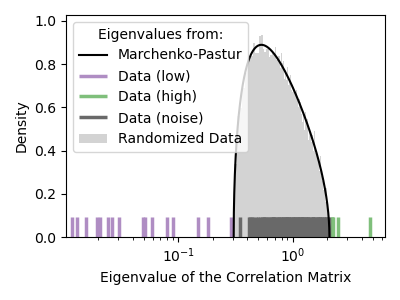

In [113]:
counts,bins = np.histogram(dummy_eigvals,density=True,
                           # bins=150,
                           bins=int(np.sqrt(len(dummy_eigvals)))
                          )
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2


'''
Draw the Marchenko-Pastur distribution
'''
lam = np.shape(data)[1]/np.shape(data)[0]
print(lam)
var=1#1.0 #as long as we consider data normalized by 1/std(x), such that we have a correlation matrix.
marchenko_pastur_min,marchenko_pastur_max = Marchenko_Pastur_significance_threshold(lam,var)
eig_x_vector,marchenko_pastur_distr = Marchenko_Pastur_distribution(marchenko_pastur_min,marchenko_pastur_max,lam,var)
print('lambda_min = {}'.format(marchenko_pastur_min))

%matplotlib widget
fig,ax = plt.subplots(figsize=(4,3))
counts,bins = np.histogram(dummy_eigvals,density=True,
                           # bins=150,
                           bins=int(np.sqrt(len(dummy_eigvals)))
                          )
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

ax.bar(bin_centers[:],counts[:],
       width=dbin*1.02,edgecolor=None,
       color = 'lightgray',
       zorder=0,
      label='Randomized Data')
ax.plot(eig_x_vector,marchenko_pastur_distr,'k',label='Marchenko-Pastur')
''' Plot the eigenvalues from the dataset '''
low_eigvals = true_eigvals[true_eigvals<marchenko_pastur_min]; true_lowvar_eigvects = true_eigvects[:,true_eigvals<marchenko_pastur_min]
if np.shape(data)[0]<np.shape(data)[1]: #less samples than species
    true_lowvar_eigvects = true_lowvar_eigvects[:,low_eigvals>1e-10] #keep nonzero eigenvalues
    low_eigvals = low_eigvals[low_eigvals>1e-10]
high_eigvals = true_eigvals[true_eigvals>marchenko_pastur_max]; true_highvar_eigvects = true_eigvects[:,true_eigvals>marchenko_pastur_max]
noise_eigvals = true_eigvals[(marchenko_pastur_min<= true_eigvals) & (true_eigvals <= marchenko_pastur_max)]
ax.vlines(low_eigvals,0,0.1*np.max(counts[1:]),
          colors=[175/255,141/255,195/255],#'tab:red',
          linewidth=2.5,zorder=0,
         label='Data (low)')
ax.vlines(high_eigvals,0,0.1*np.max(counts[1:]),
          colors=[127/255,191/255,123/255],#'tab:green',
          linewidth=2.5,zorder=0,
         label='Data (high)')
ax.vlines(noise_eigvals,0,0.1*np.max(counts[1:]),
          colors='dimgray',#'tab:orange',
          linewidth=2.5,zorder=0,
         label='Data (noise)')

ax.legend(loc='upper left',frameon=True,
          title='Eigenvalues from:')
ax.set_xlabel('Eigenvalue of the Correlation Matrix')
ax.set_ylabel('Density')
ax.set_ylim(bottom=0,top=np.max(counts[1:])*1.1)
ax.set_xscale('log'); ax.set_xlim(left=0.9*np.min(low_eigvals[low_eigvals>0]))
plt.tight_layout()

plt.savefig('{}/eigenvalue_distribution.{}.png'.format(dataset_name,dataset_name),format='png',transparent=True)
plt.savefig('{}/eigenvalue_distribution.{}.svg'.format(dataset_name,dataset_name),format='svg',transparent=True)

print(len(low_eigvals),len(high_eigvals),len(noise_eigvals))

## Calculate Overlap With inverse yields

In [114]:
import scipy as sp

#recall inv_yields is (N_resources,N_surviving_species)
consumed_resources = (np.sum(inv_yields>1e-5,axis=1)) >0 #keep only resources which are consumed
print(np.sum(consumed_resources))
not_supplied_resources = np.array([res not in supplied_resources for res in np.arange(N_resources)]) #entry_rates<1e-10 #resources that are created within the system
relevant_resources = (consumed_resources == not_supplied_resources) #Keep resources that are consumed by surviving species AND produced via cross-feeding
relevant_resources = []
for res in range(len(consumed_resources)):
    if res<independent_species_cutoff: #do not count yields for independent species
        if consumed_resources[res]==True:
            if consumed_resources[res] == not_supplied_resources[res]:
                relevant_resources.append(True)
    
            else:
                relevant_resources.append(False)
        else:
            relevant_resources.append(False)
    else:
        relevant_resources.append(False)

relevant_resources = np.array(relevant_resources)
print('relevant resource (aka present but not supplied)',
      np.arange(N_resources)[relevant_resources])


normalized_inv_yields = inv_yields.T[:,relevant_resources] #(N_surviving_species,N_relevant_resources)
normalized_inv_yields *= np.std(data,axis=0)[:,None]

normalized_inv_yields = normalized_inv_yields/np.sqrt(np.sum(normalized_inv_yields**2,axis=0))[None,:] #make norm 1

true_subspace_angles = sp.linalg.subspace_angles(
                                                 normalized_inv_yields,
                                                 true_lowvar_eigvects[:,:])
true_overlap = np.mean(np.cos(true_subspace_angles))


dummy_subspace_angles = []
dummy_overlaps = []
shuffled_species = np.arange(np.shape(true_lowvar_eigvects)[0])
dummy_eigvects = np.copy(true_lowvar_eigvects)
dummy_inv_yields = np.copy(normalized_inv_yields)
for r in range(5*N_randomizations):
    if r%100==0: print(r)
    for vec in range(np.shape(dummy_inv_yields)[1]):
        #Shuffle each eigenvectorvector
        np.random.shuffle(shuffled_species)
        dummy_inv_yields[:,vec] = dummy_inv_yields[shuffled_species,vec]

    dummy_angles = sp.linalg.subspace_angles(dummy_inv_yields,true_lowvar_eigvects)
    dummy_subspace_angles.append(dummy_angles)
    dummy_overlap = np.mean(np.cos(dummy_angles))

    dummy_overlaps.append(dummy_overlap)

20
relevant resource (aka present but not supplied) [ 2  3  4  5  6  7  8 10 12 13 15 16 17 18 19]
0
100
200
300
400


KstestResult(statistic=1.0, pvalue=0.003992015968063869, statistic_location=0.3906313099231225, statistic_sign=-1)


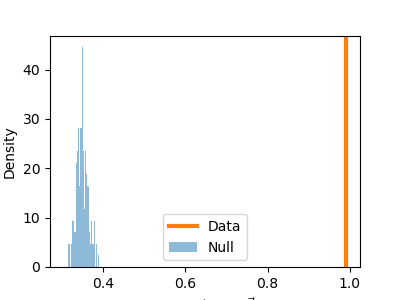

In [115]:
plt.close('all')
counts,bins = np.histogram(dummy_overlaps,density=True,bins=100)
dbin = bins[1]-bins[0]
bin_centers = bins[:-1]+dbin/2

fig,ax = plt.subplots(figsize=(4,3))
ax.bar(bin_centers,counts,
       width=dbin,
       # edgecolor='k',
       alpha=0.5,label='Null')
ax.axvline(true_overlap,linewidth=3,label='Data',color='tab:orange')
ax.legend(loc='best')
ax.set_xlabel(r'Overlap($\{ \vec{\mu}_\alpha\},\{ \vec{1/Y}_\alpha\}$)')
ax.set_ylabel('Density')

plt.savefig('{}/{}.lowvarmodes_vs_invyields_matrix_overlap.png'.format(dataset_name,dataset_name),format='png',transparent=True)
plt.savefig('{}/{}.lowvarmodes_vs_invyields_matrix_overlap.svg'.format(dataset_name,dataset_name),format='svg',transparent=True)

ks_res = sp.stats.kstest([true_overlap],dummy_overlaps,)
print(ks_res)